In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
df = pd.read_csv("Atlantic_France.csv")

In [4]:
df.head()

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
0,18-05-2024,1,LA RUE,No Limit & Gazo & Damso,72,225137,single,1,True,https://i.scdn.co/image/ab67616d0000b27384f245...
1,18-05-2024,2,C'est carré le S,Naps,74,201533,album,22,False,https://i.scdn.co/image/ab67616d0000b27348f7c1...
2,18-05-2024,3,Freestyle LVL UP 1,Ninho,76,114182,single,1,True,https://i.scdn.co/image/ab67616d0000b273fbe613...
3,18-05-2024,4,Bolide allemand,SDM,79,176746,album,15,True,https://i.scdn.co/image/ab67616d0000b273455e89...
4,18-05-2024,5,Freestyle LVL UP 2,Ninho,71,149064,single,1,True,https://i.scdn.co/image/ab67616d0000b27351f1cb...


In [7]:
df.tail()

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
27795,27-11-2025,46,Mauvais garçon,Helena,63,162706,single,1,False,https://i.scdn.co/image/ab67616d0000b2731ad45d...
27796,27-11-2025,47,Laboratoire,Werenoi,71,162840,album,18,True,https://i.scdn.co/image/ab67616d0000b273454178...
27797,27-11-2025,48,Coco,Ninho & Niska,66,148656,album,15,True,https://i.scdn.co/image/ab67616d0000b273d30660...
27798,27-11-2025,49,Nightcall,Kavinsky & Angèle & Phoenix,74,179306,single,1,False,https://i.scdn.co/image/ab67616d0000b27382e856...
27799,27-11-2025,50,Paint The Town Blue (from the series Arcane Le...,Ashnikko & Arcane & League of Legends,76,115533,single,1,False,https://i.scdn.co/image/ab67616d0000b273b6d68c...


In [8]:
df.shape

(27800, 10)

In [9]:
df.columns

Index(['date', 'position', 'song', 'artist', 'popularity', 'duration_ms',
       'album_type', 'total_tracks', 'is_explicit', 'album_cover_url'],
      dtype='object')

In [10]:
df.dtypes

date               object
position            int64
song               object
artist             object
popularity          int64
duration_ms         int64
album_type         object
total_tracks        int64
is_explicit          bool
album_cover_url    object
dtype: object

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27800 entries, 0 to 27799
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   date             27800 non-null  object
 1   position         27800 non-null  int64 
 2   song             27799 non-null  object
 3   artist           27800 non-null  object
 4   popularity       27800 non-null  int64 
 5   duration_ms      27800 non-null  int64 
 6   album_type       27800 non-null  object
 7   total_tracks     27800 non-null  int64 
 8   is_explicit      27800 non-null  bool  
 9   album_cover_url  27800 non-null  object
dtypes: bool(1), int64(4), object(5)
memory usage: 1.9+ MB


In [12]:
df.describe()

,position,popularity,duration_ms,total_tracks
count,27800.000000,27800.000000,27800.000000,27800.000000
mean,25.500000,76.645108,185474.848165,8.999856
std,14.431129,11.570874,32436.845058,8.140060
min,1.000000,0.000000,0.000000,1.000000
25%,13.000000,71.000000,165586.000000,1.000000
50%,25.500000,75.000000,180000.000000,10.000000
75%,38.000000,83.000000,207733.000000,15.000000
max,50.000000,100.000000,547413.000000,119.000000


In [13]:
df.isnull().sum()

date               0
position           0
song               1
artist             0
popularity         0
duration_ms        0
album_type         0
total_tracks       0
is_explicit        0
album_cover_url    0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(19)

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df["date"]=pd.to_datetime(df["date"], format="%d-%m-%Y")

In [17]:
df["duration_min"] = df["duration_ms"] / 60000

In [18]:
df["album_type"].value_counts()

album_type
album          14686
single         13086
compilation        9
Name: count, dtype: int64

In [19]:
df["is_explicit"].value_counts()

is_explicit
True     15629
False    12152
Name: count, dtype: int64

In [20]:
df["artist"].nunique()
print("artist")

artist


In [21]:
df["song"].nunique()

695

In [22]:
df.to_csv("Atlantic_France_Cleaned.csv", index=False)

In [23]:
print("Total Records :", len(df))

Total Records : 27781


In [25]:
print("Total Columns :", len(df.columns))

Total Columns : 11


In [26]:
print("Unique Songs :", df["song"].nunique())

Unique Songs : 695


In [27]:
print("Unique Artists :", df["artist"].nunique())

Unique Artists : 325


In [28]:
print("Average Popularity :", round(df["popularity"].mean(),2))

Average Popularity : 76.64


In [29]:
print("Average Duration :", round(df["duration_min"].mean(),2),"Minutes")

Average Duration : 3.09 Minutes


In [30]:
print("Average Album Size :", round(df["total_tracks"].mean(),2))

Average Album Size : 9.0


In [31]:
df["is_explicit"].value_counts()

is_explicit
True     15629
False    12152
Name: count, dtype: int64

In [32]:
(df["is_explicit"].value_counts(normalize=True)*100).round(2)

is_explicit
True     56.26
False    43.74
Name: proportion, dtype: float64

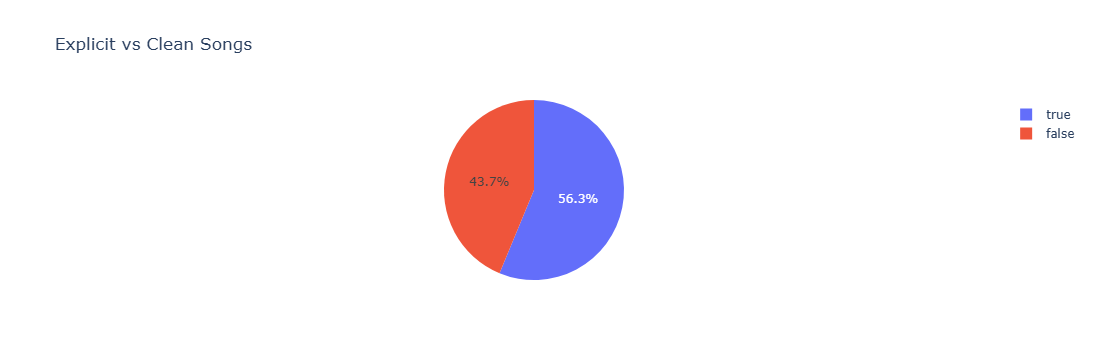

In [33]:
px.pie(df,names="is_explicit",title="Explicit vs Clean Songs")

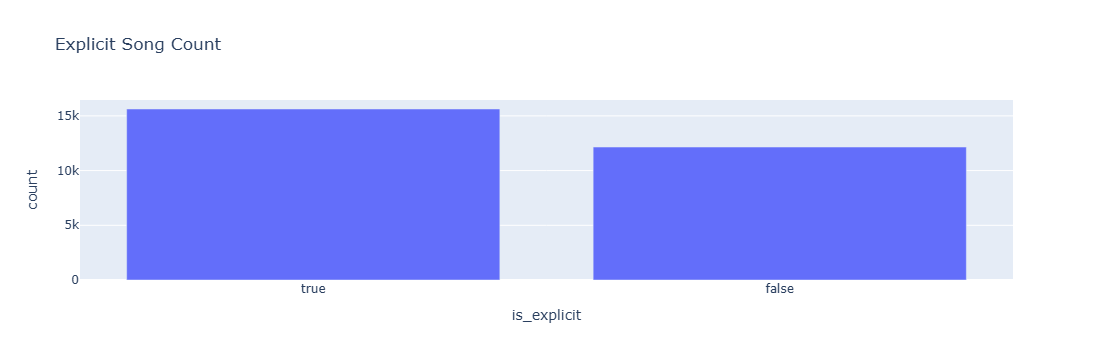

In [34]:
px.bar(df["is_explicit"].value_counts().reset_index(),x="is_explicit",y="count",title="Explicit Song Count")

In [35]:
df.groupby("is_explicit")["popularity"].mean()

is_explicit
False    80.901333
True     73.330795
Name: popularity, dtype: float64

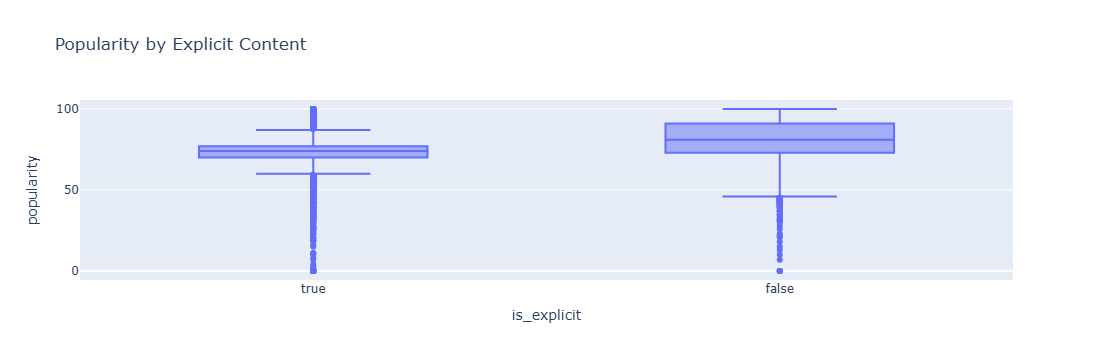

In [36]:
px.box(df,x="is_explicit",y="popularity",title="Popularity by Explicit Content")

In [37]:
df["album_type"].value_counts()

album_type
album          14686
single         13086
compilation        9
Name: count, dtype: int64

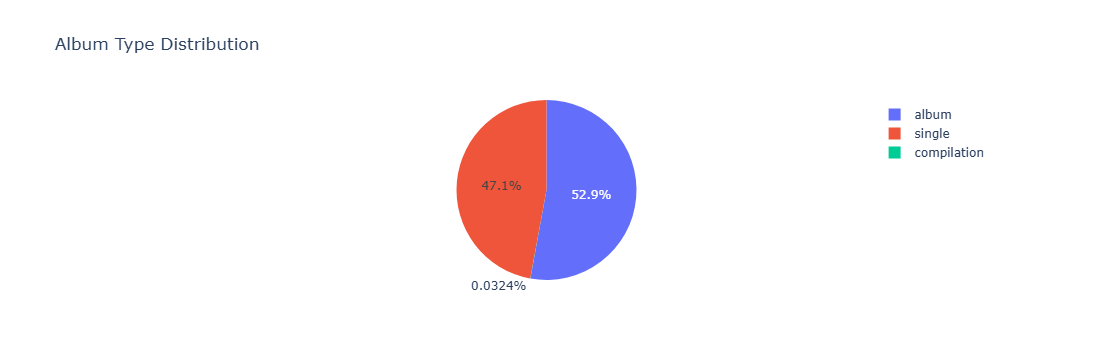

In [38]:
px.pie(df,names="album_type",title="Album Type Distribution")

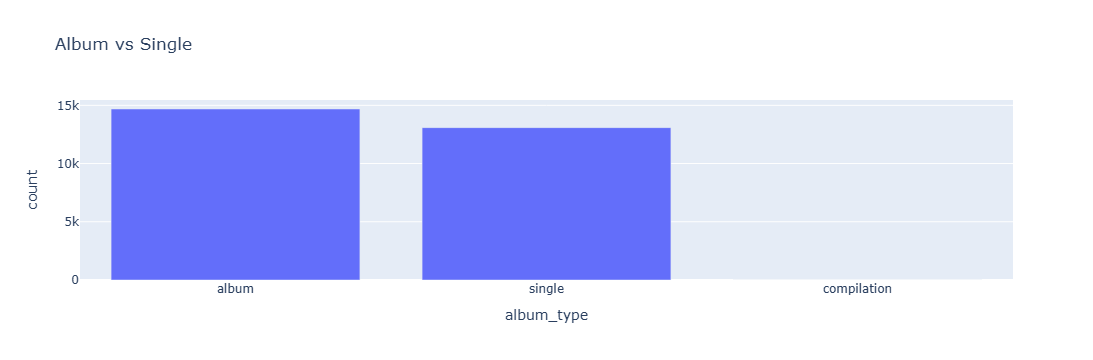

In [39]:
px.bar(df["album_type"].value_counts().reset_index(),x="album_type",y="count",title="Album vs Single")

In [40]:
df.groupby("album_type")["popularity"].mean()

album_type
album          72.986313
compilation    79.333333
single         80.743466
Name: popularity, dtype: float64

In [41]:
df.groupby("album_type")["duration_min"].mean()

album_type
album          3.158625
compilation    2.913154
single         3.015722
Name: duration_min, dtype: float64

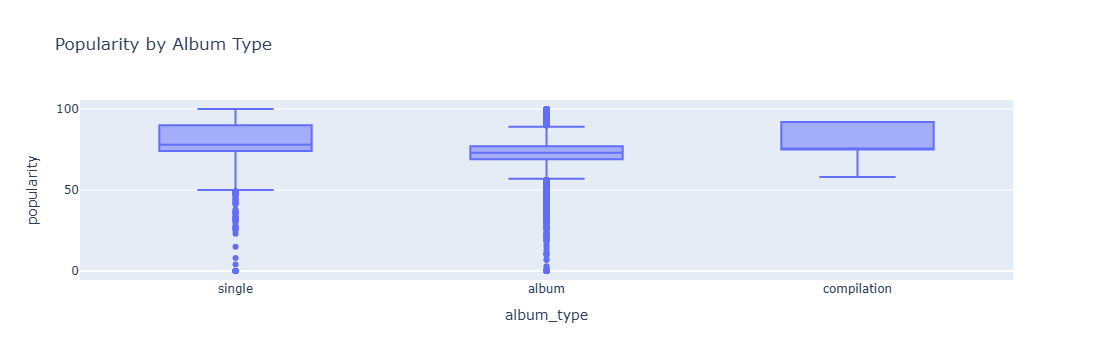

In [42]:
px.box(df,x="album_type",y="popularity",title="Popularity by Album Type")

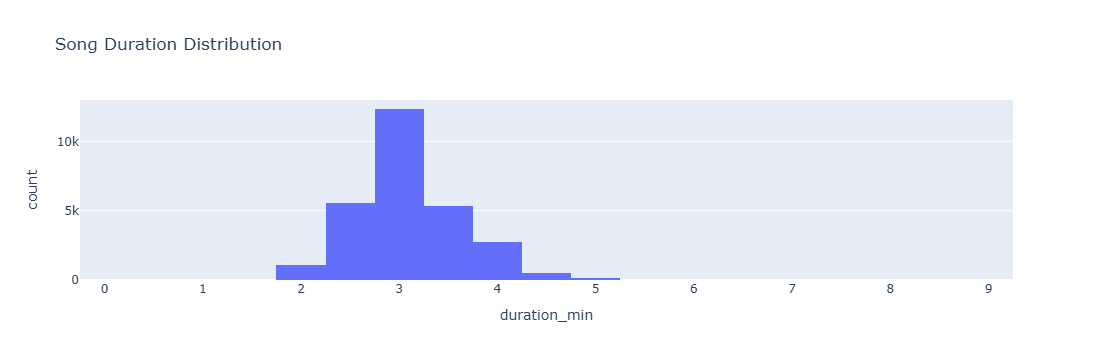

In [43]:
px.histogram(df,x="duration_min",nbins=30,title="Song Duration Distribution")

In [44]:
df["duration_min"].mean()

np.float64(3.0912319414947866)

In [45]:
df["duration_min"].min()

np.float64(0.0)

In [46]:
df["duration_min"].max()

np.float64(9.12355)

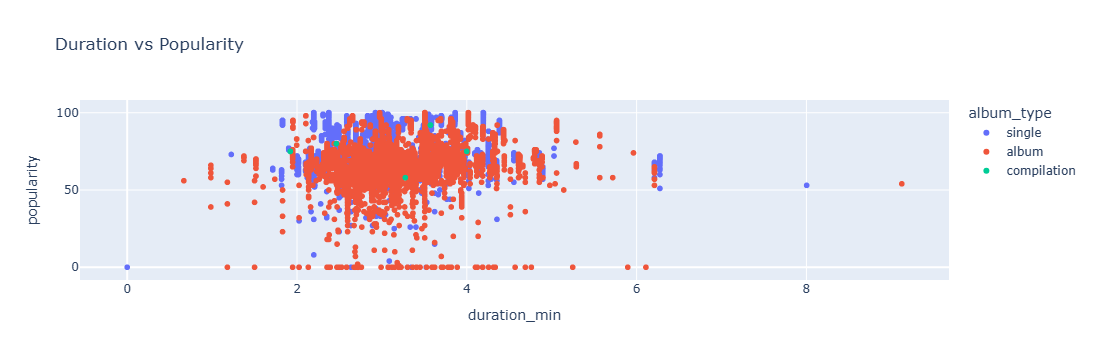

In [47]:
px.scatter(df,x="duration_min",y="popularity",color="album_type",title="Duration vs Popularity")

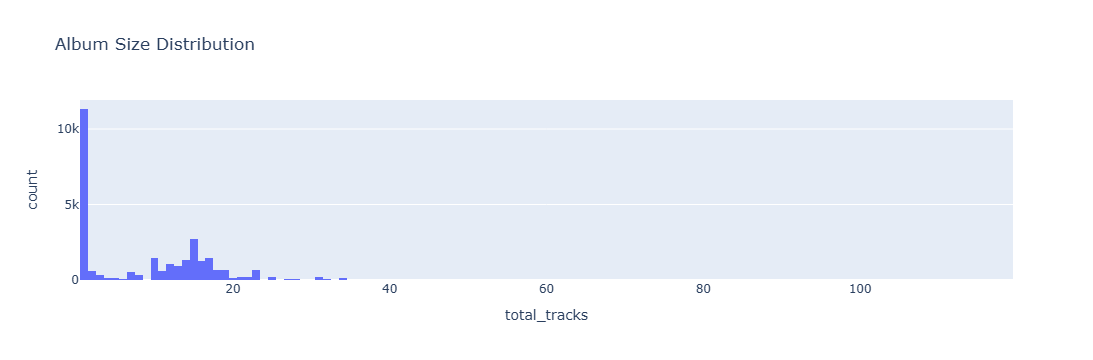

In [48]:
px.histogram(df,x="total_tracks",title="Album Size Distribution")

In [49]:
df["total_tracks"].mean()

np.float64(9.001115870559016)

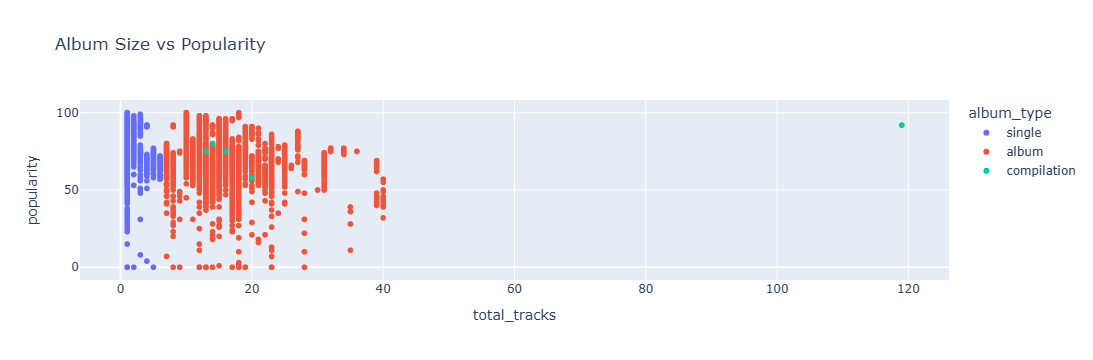

In [50]:
px.scatter(df,x="total_tracks",y="popularity",color="album_type",title="Album Size vs Popularity")

In [51]:
top_artist = df["artist"].value_counts().head(10)

top_artist

artist
Werenoi     2201
PLK          905
SDM          901
Jul          711
Ninho        622
Favé         597
Tiakola      594
GIMS         559
KeBlack      546
Dua Lipa     488
Name: count, dtype: int64

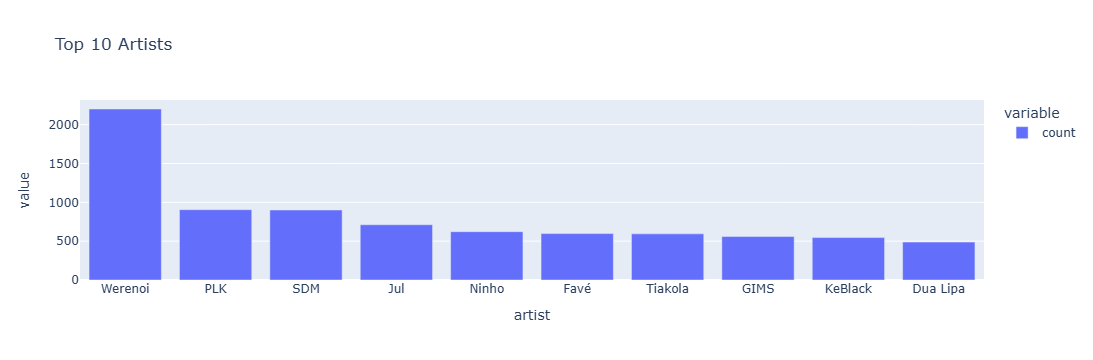

In [52]:
px.bar(top_artist,title="Top 10 Artists")

In [53]:
top_song = df.sort_values("popularity",ascending=False).head(10)

top_song

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url,duration_min
26658,2025-11-05,9,Die With A Smile,Lady Gaga & Bruno Mars,100,251667,single,1,False,https://i.scdn.co/image/ab67616d0000b27382ea2e...,4.194450
27761,2025-11-27,12,Die With A Smile,Lady Gaga & Bruno Mars,100,251667,single,1,False,https://i.scdn.co/image/ab67616d0000b27382ea2e...,4.194450
22864,2025-08-21,15,BIRDS OF A FEATHER,Billie Eilish,100,210373,album,10,False,https://i.scdn.co/image/ab67616d0000b27371d62e...,3.506217
26757,2025-11-07,8,Die With A Smile,Lady Gaga & Bruno Mars,100,251667,single,1,False,https://i.scdn.co/image/ab67616d0000b27382ea2e...,4.194450
12411,2025-01-21,12,greedy,Tate McRae,100,131872,single,1,True,https://i.scdn.co/image/ab67616d0000b27322fd80...,2.197867
12507,2025-01-23,8,greedy,Tate McRae,100,131872,single,1,True,https://i.scdn.co/image/ab67616d0000b27322fd80...,2.197867
17207,2025-04-28,8,i like the way you kiss me,Artemas,100,142514,single,1,False,https://i.scdn.co/image/ab67616d0000b273e67611...,2.375233
12762,2025-01-28,13,greedy,Tate McRae,100,131872,single,1,True,https://i.scdn.co/image/ab67616d0000b27322fd80...,2.197867
24912,2025-10-01,13,Die With A Smile,Lady Gaga & Bruno Mars,100,251667,single,1,False,https://i.scdn.co/image/ab67616d0000b27382ea2e...,4.194450
10959,2024-12-23,10,All I Want for Christmas Is You,Mariah Carey,100,241106,album,10,False,https://i.scdn.co/image/ab67616d0000b2734246e3...,4.018433


In [2]:
import plotly.express as px

In [3]:
px.bar(top_song,x="song",y="popularity",color="artist",title="Top 10 Popular Songs")

NameError: name 'top_song' is not defined

In [4]:
import pandas as pd

df = pd.read_csv("Atlantic_France.csv")

In [5]:
df.head()

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
0,18-05-2024,1,LA RUE,No Limit & Gazo & Damso,72,225137,single,1,True,https://i.scdn.co/image/ab67616d0000b27384f245...
1,18-05-2024,2,C'est carré le S,Naps,74,201533,album,22,False,https://i.scdn.co/image/ab67616d0000b27348f7c1...
2,18-05-2024,3,Freestyle LVL UP 1,Ninho,76,114182,single,1,True,https://i.scdn.co/image/ab67616d0000b273fbe613...
3,18-05-2024,4,Bolide allemand,SDM,79,176746,album,15,True,https://i.scdn.co/image/ab67616d0000b273455e89...
4,18-05-2024,5,Freestyle LVL UP 2,Ninho,71,149064,single,1,True,https://i.scdn.co/image/ab67616d0000b27351f1cb...


In [6]:
top_song = df.sort_values(
    by="popularity",
    ascending=False
).head(10)

top_song

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
27612,24-11-2025,13,Die With A Smile,Lady Gaga & Bruno Mars,100,251667,single,1,False,https://i.scdn.co/image/ab67616d0000b27382ea2e...
27761,27-11-2025,12,Die With A Smile,Lady Gaga & Bruno Mars,100,251667,single,1,False,https://i.scdn.co/image/ab67616d0000b27382ea2e...
9007,14-11-2024,8,greedy,Tate McRae,100,131872,single,1,True,https://i.scdn.co/image/ab67616d0000b27322fd80...
27712,26-11-2025,13,Die With A Smile,Lady Gaga & Bruno Mars,100,251667,single,1,False,https://i.scdn.co/image/ab67616d0000b27382ea2e...
24666,26-09-2025,17,Die With A Smile,Lady Gaga & Bruno Mars,100,251667,single,1,False,https://i.scdn.co/image/ab67616d0000b27382ea2e...
27662,25-11-2025,13,Die With A Smile,Lady Gaga & Bruno Mars,100,251667,single,1,False,https://i.scdn.co/image/ab67616d0000b27382ea2e...
27463,21-11-2025,14,Die With A Smile,Lady Gaga & Bruno Mars,100,251667,single,1,False,https://i.scdn.co/image/ab67616d0000b27382ea2e...
27511,22-11-2025,12,Die With A Smile,Lady Gaga & Bruno Mars,100,251667,single,1,False,https://i.scdn.co/image/ab67616d0000b27382ea2e...
24492,22-09-2025,43,BIRDS OF A FEATHER,Billie Eilish,100,210373,album,10,False,https://i.scdn.co/image/ab67616d0000b27371d62e...
15700,29-03-2025,1,Beautiful Things,Benson Boone,100,180304,single,1,False,https://i.scdn.co/image/ab67616d0000b273f2a919...


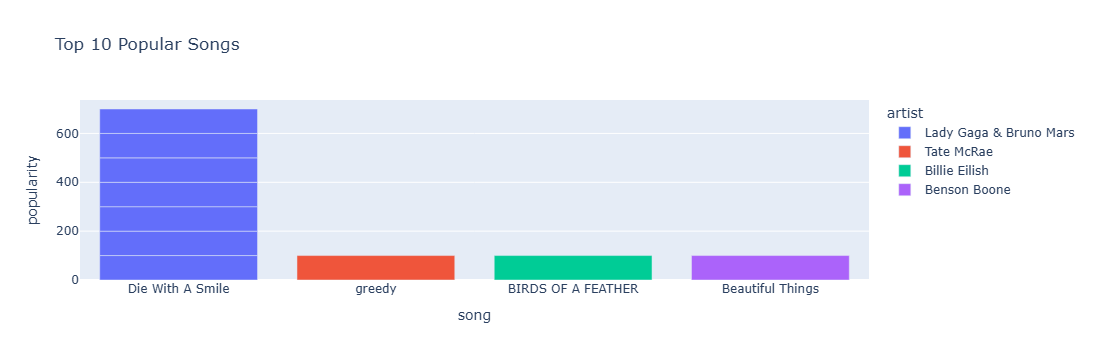

In [7]:
import plotly.express as px

fig = px.bar(
    top_song,
    x="song",
    y="popularity",
    color="artist",
    title="Top 10 Popular Songs"
)

fig.show()

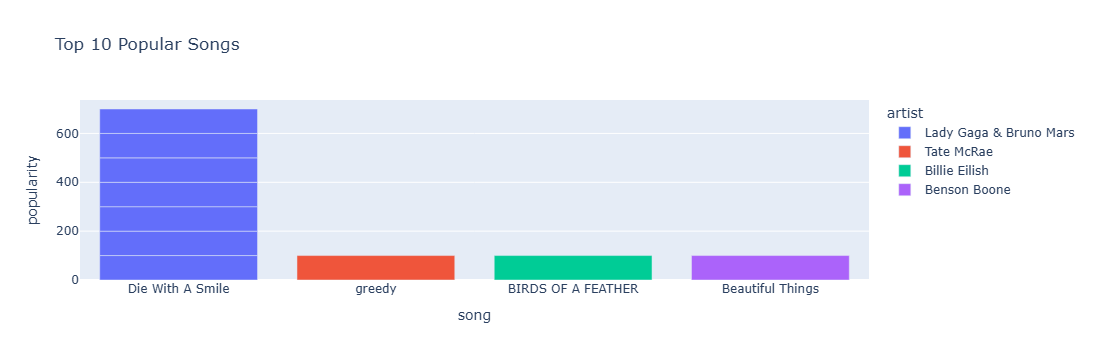

In [8]:
px.bar(
    top_song,
    x="song",
    y="popularity",
    color="artist",
    title="Top 10 Popular Songs"
)

In [9]:
df.corr(numeric_only=True)

,position,popularity,duration_ms,total_tracks,is_explicit
position,1.000000,-0.117417,0.017552,0.106880,-0.040214
popularity,-0.117417,1.000000,0.055922,-0.342541,-0.324487
duration_ms,0.017552,0.055922,1.000000,0.118641,0.080068
total_tracks,0.106880,-0.342541,0.118641,1.000000,0.351738
is_explicit,-0.040214,-0.324487,0.080068,0.351738,1.000000


In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

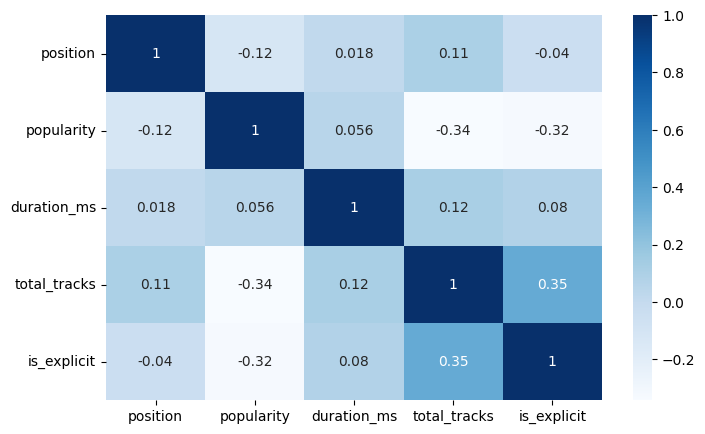

In [12]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="Blues"
)

plt.show()

In [13]:
total_records = len(df)
print("Total Records:", total_records)

Total Records: 27800


In [14]:
total_songs = df["song"].nunique()
print("Unique Songs:", total_songs)

Unique Songs: 695


In [15]:
total_artists = df["artist"].nunique()
print("Unique Artists:", total_artists)

Unique Artists: 325


In [16]:
avg_popularity = round(df["popularity"].mean(),2)
print("Average Popularity:", avg_popularity)

Average Popularity: 76.65


In [17]:
max_popularity = df["popularity"].max()
print("Highest Popularity:", max_popularity)

Highest Popularity: 100


In [18]:
min_popularity = df["popularity"].min()
print("Lowest Popularity:", min_popularity)

Lowest Popularity: 0


In [20]:
df.columns

Index(['date', 'position', 'song', 'artist', 'popularity', 'duration_ms',
       'album_type', 'total_tracks', 'is_explicit', 'album_cover_url'],
      dtype='object')

In [21]:
df["duration_min"] = df["duration_ms"] / 60000

In [22]:
df[["duration_ms", "duration_min"]].head()

,duration_ms,duration_min
0,225137,3.752283
1,201533,3.358883
2,114182,1.903033
3,176746,2.945767
4,149064,2.484400


In [23]:
avg_duration = round(df["duration_min"].mean(), 2)
print("Average Duration:", avg_duration, "Minutes")

Average Duration: 3.09 Minutes


In [24]:
longest_song = round(df["duration_min"].max(),2)
print("Longest Song:", longest_song,"Minutes")

Longest Song: 9.12 Minutes


In [25]:
shortest_song = round(df["duration_min"].min(),2)
print("Shortest Song:", shortest_song,"Minutes")

Shortest Song: 0.0 Minutes


In [26]:
avg_tracks = round(df["total_tracks"].mean(),2)
print("Average Album Size:", avg_tracks)

Average Album Size: 9.0


In [27]:
explicit_count = df["is_explicit"].sum()
print("Explicit Songs:", explicit_count)

Explicit Songs: 15640


In [28]:
clean_count = len(df) - explicit_count
print("Clean Songs:", clean_count)

Clean Songs: 12160


In [29]:
explicit_percent = round((explicit_count/len(df))*100,2)
print("Explicit %:", explicit_percent)

Explicit %: 56.26


In [30]:
df["album_type"].value_counts()

album_type
album          14695
single         13096
compilation        9
Name: count, dtype: int64

In [31]:
album_percent = round((df["album_type"]=="album").mean()*100,2)
print("Album %:", album_percent)

Album %: 52.86


In [32]:
single_percent = round((df["album_type"]=="single").mean()*100,2)
print("Single %:", single_percent)

Single %: 47.11


In [33]:
top_artists = df["artist"].value_counts().head(10)
print(top_artists)

artist
Werenoi     2206
PLK          906
SDM          901
Jul          711
Ninho        622
Favé         597
Tiakola      594
GIMS         559
KeBlack      546
Dua Lipa     489
Name: count, dtype: int64


In [34]:
top_songs = df.sort_values("popularity",ascending=False)[["song","artist","popularity"]].head(10)
top_songs

,song,artist,popularity
27612,Die With A Smile,Lady Gaga & Bruno Mars,100
27761,Die With A Smile,Lady Gaga & Bruno Mars,100
9007,greedy,Tate McRae,100
27712,Die With A Smile,Lady Gaga & Bruno Mars,100
24666,Die With A Smile,Lady Gaga & Bruno Mars,100
27662,Die With A Smile,Lady Gaga & Bruno Mars,100
27463,Die With A Smile,Lady Gaga & Bruno Mars,100
27511,Die With A Smile,Lady Gaga & Bruno Mars,100
24492,BIRDS OF A FEATHER,Billie Eilish,100
15700,Beautiful Things,Benson Boone,100


In [35]:
top_albums = df.groupby("album_type")["popularity"].mean()
print(top_albums)

album_type
album          72.987138
compilation    79.333333
single         80.747862
Name: popularity, dtype: float64


In [36]:
kpi_df = pd.DataFrame({
    "KPI": ["Total Records","Unique Songs","Unique Artists","Average Popularity","Average Duration (min)","Explicit %","Album %","Single %"],
    "Value": [total_records,total_songs,total_artists,avg_popularity,avg_duration,explicit_percent,album_percent,single_percent]
})

kpi_df

,KPI,Value
0,Total Records,27800.00
1,Unique Songs,695.00
2,Unique Artists,325.00
3,Average Popularity,76.65
4,Average Duration (min),3.09
5,Explicit %,56.26
6,Album %,52.86
7,Single %,47.11


In [37]:
kpi_df.to_csv("kpi_summary.csv", index=False)